Shape: (250, 9)
   Age   BMI  Glucose  BloodPressure  Insulin PhysicalActivity  FamilyHistory  \
0   58  26.9      170            103      222              Low              0   
1   71  19.4      168             84      179           Medium              1   
2   48  23.6      105             76      204              Low              0   
3   34  23.4      165             72      144           Medium              0   
4   62  33.3      106             79      164           Medium              1   

   Smoking  Outcome  
0        1        1  
1        1        1  
2        1        0  
3        1        1  
4        0        1  

Data Types:
 Age                   int64
BMI                 float64
Glucose               int64
BloodPressure         int64
Insulin               int64
PhysicalActivity     object
FamilyHistory         int64
Smoking               int64
Outcome               int64
dtype: object

Missing Values:
 Age                 0
BMI                 0
Glucose             0
B

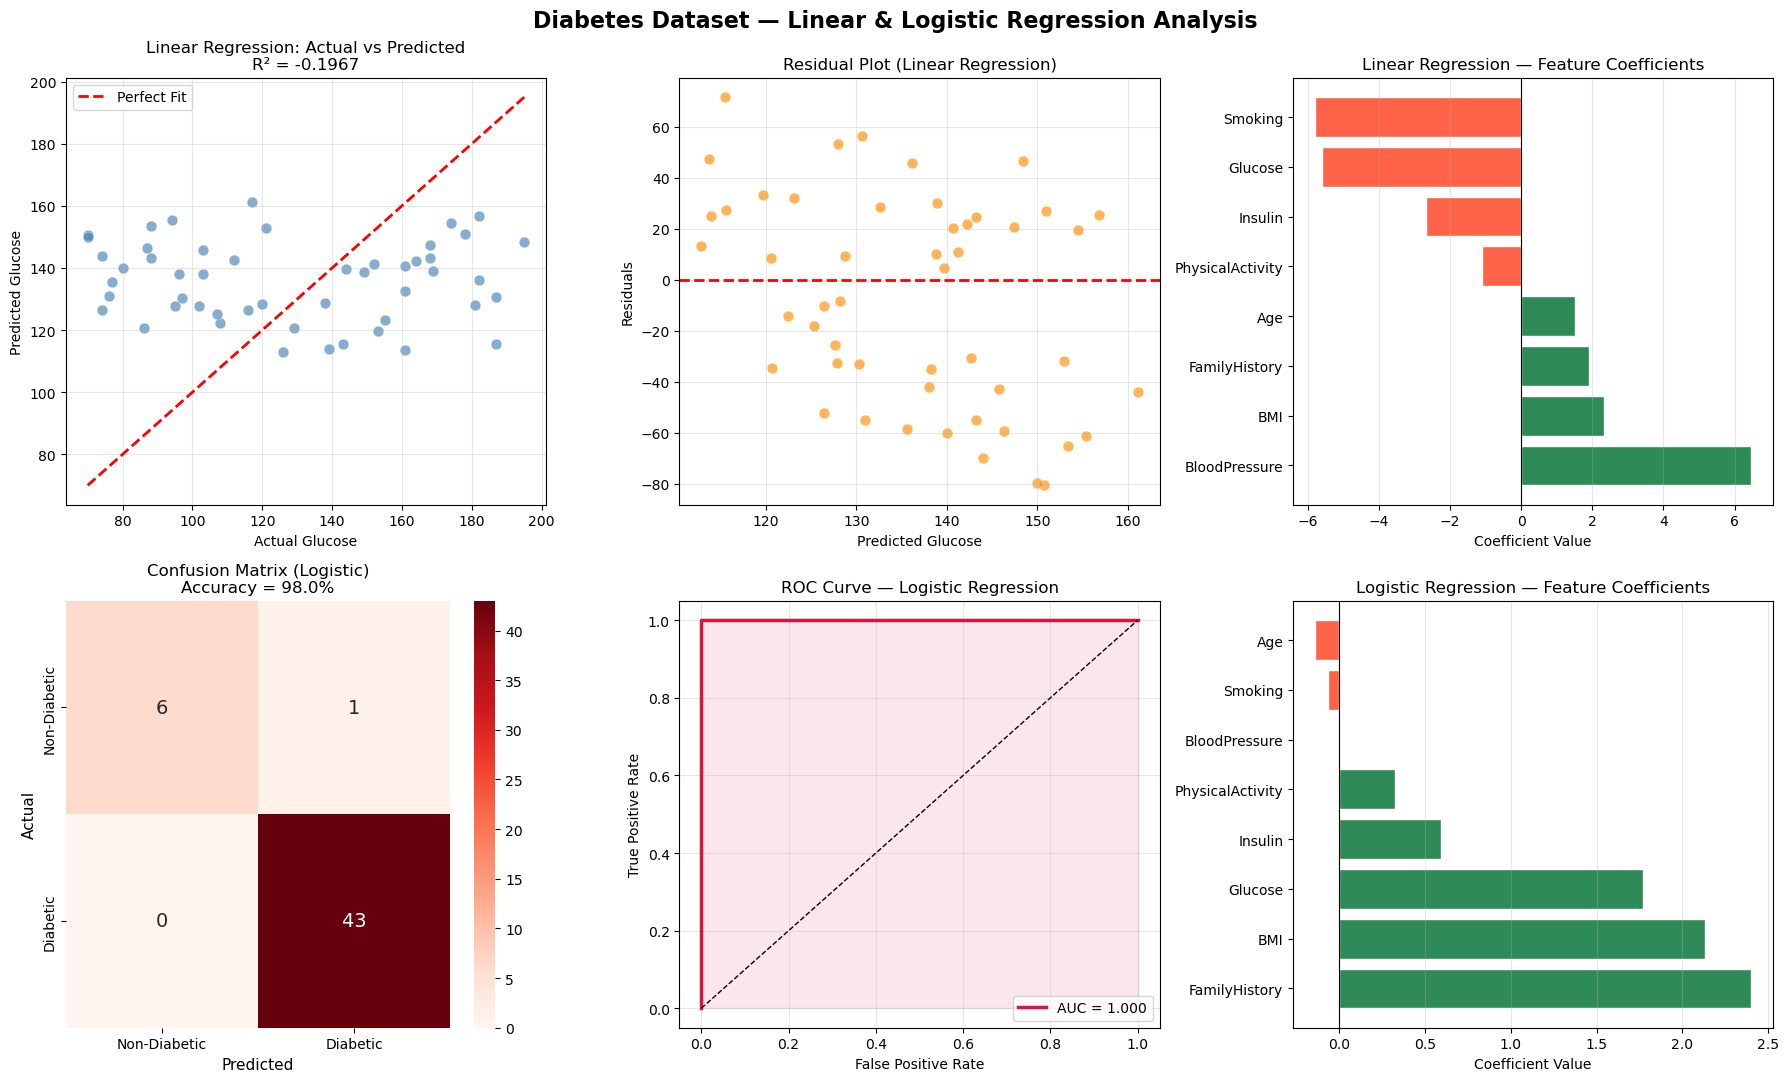


✅ Plot saved as diabetes_regression_results.png


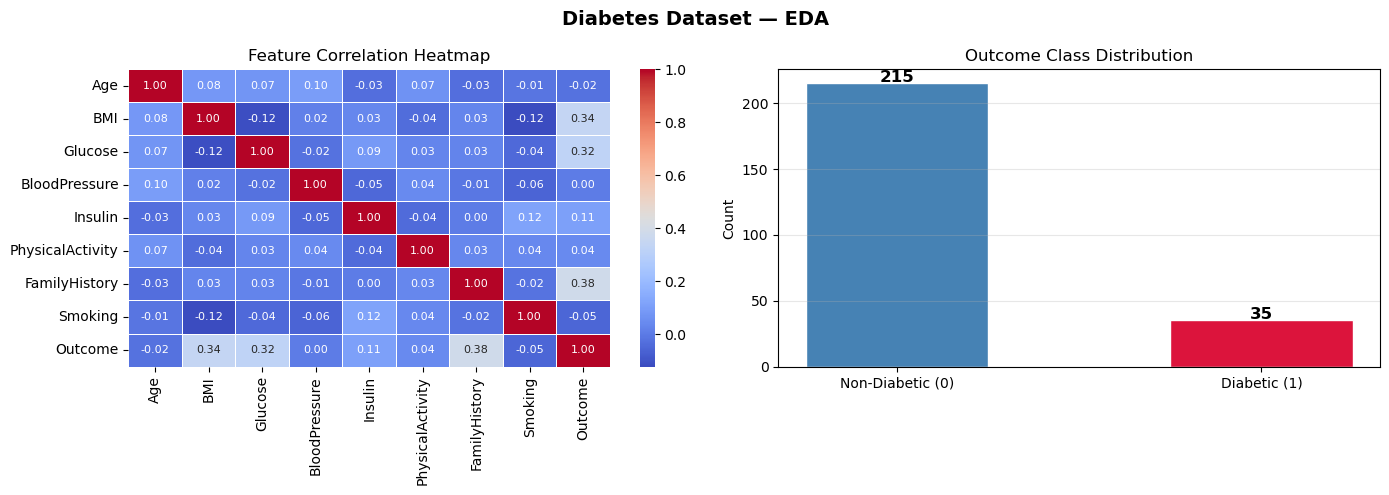

✅ EDA plot saved as diabetes_eda.png

      Sample Predictions (first 10 test rows)
 Actual Glucose  Predicted Glucose Actual Outcome Predicted Outcome
            161              140.7       Diabetic          Diabetic
            182              136.2       Diabetic          Diabetic
             97              130.3   Non-Diabetic          Diabetic
            108              122.4       Diabetic          Diabetic
            187              130.6   Non-Diabetic      Non-Diabetic
            112              142.6       Diabetic          Diabetic
            161              113.7       Diabetic          Diabetic
            149              138.8       Diabetic          Diabetic
            168              143.3       Diabetic          Diabetic
            116              126.4   Non-Diabetic      Non-Diabetic


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. LOAD & PREPROCESS DATA
# ─────────────────────────────────────────────
df = pd.read_csv("diabetes_dataset_250.csv")
print("Shape:", df.shape)
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nOutcome Distribution:\n", df["Outcome"].value_counts())

# Encode PhysicalActivity (Low=0, Medium=1, High=2)
activity_map = {"Low": 0, "Medium": 1, "High": 2}
df["PhysicalActivity"] = df["PhysicalActivity"].map(activity_map)

# Feature columns
feature_cols = ["Age", "BMI", "Glucose", "BloodPressure",
                "Insulin", "PhysicalActivity", "FamilyHistory", "Smoking"]

X     = df[feature_cols]
y_cls = df["Outcome"]          # Binary: 1=Diabetic, 0=Non-Diabetic  → Logistic Regression
y_reg = df["Glucose"]          # Continuous: predict Glucose level    → Linear Regression

# Train-test split
X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
_,       _,      yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 2. LINEAR REGRESSION  (predict Glucose level)
# ─────────────────────────────────────────────
print("\n" + "="*58)
print("     LINEAR REGRESSION — Predicting Glucose Level")
print("="*58)

lr_model = LinearRegression()
lr_model.fit(Xtr_sc, yr_train)
yr_pred  = lr_model.predict(Xte_sc)

mae  = mean_absolute_error(yr_test, yr_pred)
mse  = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2   = r2_score(yr_test, yr_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Coefficients table
coef_df = pd.DataFrame({
    "Feature":     feature_cols,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)
print("\nFeature Coefficients:\n", coef_df.to_string(index=False))

# ─────────────────────────────────────────────
# 3. LOGISTIC REGRESSION  (Diabetic / Non-Diabetic)
# ─────────────────────────────────────────────
print("\n" + "="*58)
print("     LOGISTIC REGRESSION — Diabetic (1) vs Non-Diabetic (0)")
print("="*58)

log_model    = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(Xtr_sc, yc_train)
yc_pred      = log_model.predict(Xte_sc)
yc_pred_prob = log_model.predict_proba(Xte_sc)[:, 1]

acc = accuracy_score(yc_test, yc_pred)
print(f"Accuracy : {acc*100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(yc_test, yc_pred, target_names=["Non-Diabetic", "Diabetic"]))

# ─────────────────────────────────────────────
# 4. VISUALISATIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Diabetes Dataset — Linear & Logistic Regression Analysis",
             fontsize=16, fontweight="bold")

# ── Plot 1: Actual vs Predicted Glucose (Linear) ──
ax = axes[0, 0]
ax.scatter(yr_test, yr_pred, alpha=0.65, color="steelblue",
           edgecolors="white", linewidth=0.4, s=60)
mn, mx = yr_test.min(), yr_test.max()
ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Fit")
ax.set_xlabel("Actual Glucose")
ax.set_ylabel("Predicted Glucose")
ax.set_title(f"Linear Regression: Actual vs Predicted\nR² = {r2:.4f}")
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 2: Residuals (Linear) ──
ax = axes[0, 1]
residuals = yr_test.values - yr_pred
ax.scatter(yr_pred, residuals, alpha=0.65, color="darkorange",
           edgecolors="white", linewidth=0.4, s=60)
ax.axhline(0, color="red", lw=2, ls="--")
ax.set_xlabel("Predicted Glucose")
ax.set_ylabel("Residuals")
ax.set_title("Residual Plot (Linear Regression)")
ax.grid(alpha=0.3)

# ── Plot 3: Feature Coefficients (Linear) ──
ax = axes[0, 2]
colors_lr = ["seagreen" if c > 0 else "tomato" for c in coef_df["Coefficient"]]
bars = ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_lr, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Linear Regression — Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.grid(axis="x", alpha=0.3)

# ── Plot 4: Confusion Matrix (Logistic) ──
ax = axes[1, 0]
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax,
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"],
            annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"Confusion Matrix (Logistic)\nAccuracy = {acc*100:.1f}%")

# ── Plot 5: ROC Curve (Logistic) ──
ax = axes[1, 1]
fpr, tpr, _ = roc_curve(yc_test, yc_pred_prob)
roc_auc     = auc(fpr, tpr)
ax.plot(fpr, tpr, color="crimson", lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax.fill_between(fpr, tpr, alpha=0.1, color="crimson")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# ── Plot 6: Feature Coefficients (Logistic) ──
ax = axes[1, 2]
log_coef = pd.DataFrame({
    "Feature":     feature_cols,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)
colors_log = ["seagreen" if c > 0 else "tomato" for c in log_coef["Coefficient"]]
ax.barh(log_coef["Feature"], log_coef["Coefficient"],
        color=colors_log, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Logistic Regression — Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("diabetes_regression_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Plot saved as diabetes_regression_results.png")

# ─────────────────────────────────────────────
# 5. BONUS — EDA: Correlation Heatmap
# ─────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Diabetes Dataset — EDA", fontsize=14, fontweight="bold")

# Correlation heatmap
ax = axes2[0]
corr = df[feature_cols + ["Outcome"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
            annot_kws={"size": 8}, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap")

# Outcome distribution
ax = axes2[1]
outcome_counts = df["Outcome"].value_counts()
bars = ax.bar(["Non-Diabetic (0)", "Diabetic (1)"],
              outcome_counts.values,
              color=["steelblue", "crimson"], edgecolor="white", width=0.5)
for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha="center", fontweight="bold", fontsize=12)
ax.set_title("Outcome Class Distribution")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("diabetes_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plot saved as diabetes_eda.png")

# ─────────────────────────────────────────────
# 6. SAMPLE PREDICTIONS
# ─────────────────────────────────────────────
print("\n" + "="*58)
print("      Sample Predictions (first 10 test rows)")
print("="*58)
sample = pd.DataFrame({
    "Actual Glucose"    : yr_test.values[:10],
    "Predicted Glucose" : np.round(yr_pred[:10], 1),
    "Actual Outcome"    : ["Diabetic" if v else "Non-Diabetic" for v in yc_test.values[:10]],
    "Predicted Outcome" : ["Diabetic" if v else "Non-Diabetic" for v in yc_pred[:10]]
})
print(sample.to_string(index=False))

         DIABETES MODEL TRAINING PIPELINE

✅ Dataset loaded  →  250 rows, 9 columns

Outcome Distribution:
Outcome
1    215
0     35

📊 Train size : 200 samples
📊 Test  size : 50 samples

💾 Scaler saved  →  saved_models/scaler.pkl

           TRAINING & EVALUATING ALL MODELS

🔄 Training  →  Logistic Regression ...
   ✔ Test Accuracy : 98.00%
   ✔ AUC Score     : 1.0000
   ✔ CV Accuracy   : 93.50%  (5-fold)
   💾 Saved  →  saved_models/logistic_regression.pkl

🔄 Training  →  K-Nearest Neighbors ...
   ✔ Test Accuracy : 92.00%
   ✔ AUC Score     : 0.9934
   ✔ CV Accuracy   : 90.00%  (5-fold)
   💾 Saved  →  saved_models/k-nearest_neighbors.pkl

🔄 Training  →  Random Forest ...
   ✔ Test Accuracy : 94.00%
   ✔ AUC Score     : 1.0000
   ✔ CV Accuracy   : 96.00%  (5-fold)
   💾 Saved  →  saved_models/random_forest.pkl

🔄 Training  →  Gradient Boosting ...
   ✔ Test Accuracy : 100.00%
   ✔ AUC Score     : 1.0000
   ✔ CV Accuracy   : 98.50%  (5-fold)
   💾 Saved  →  saved_models/gradient_boosting

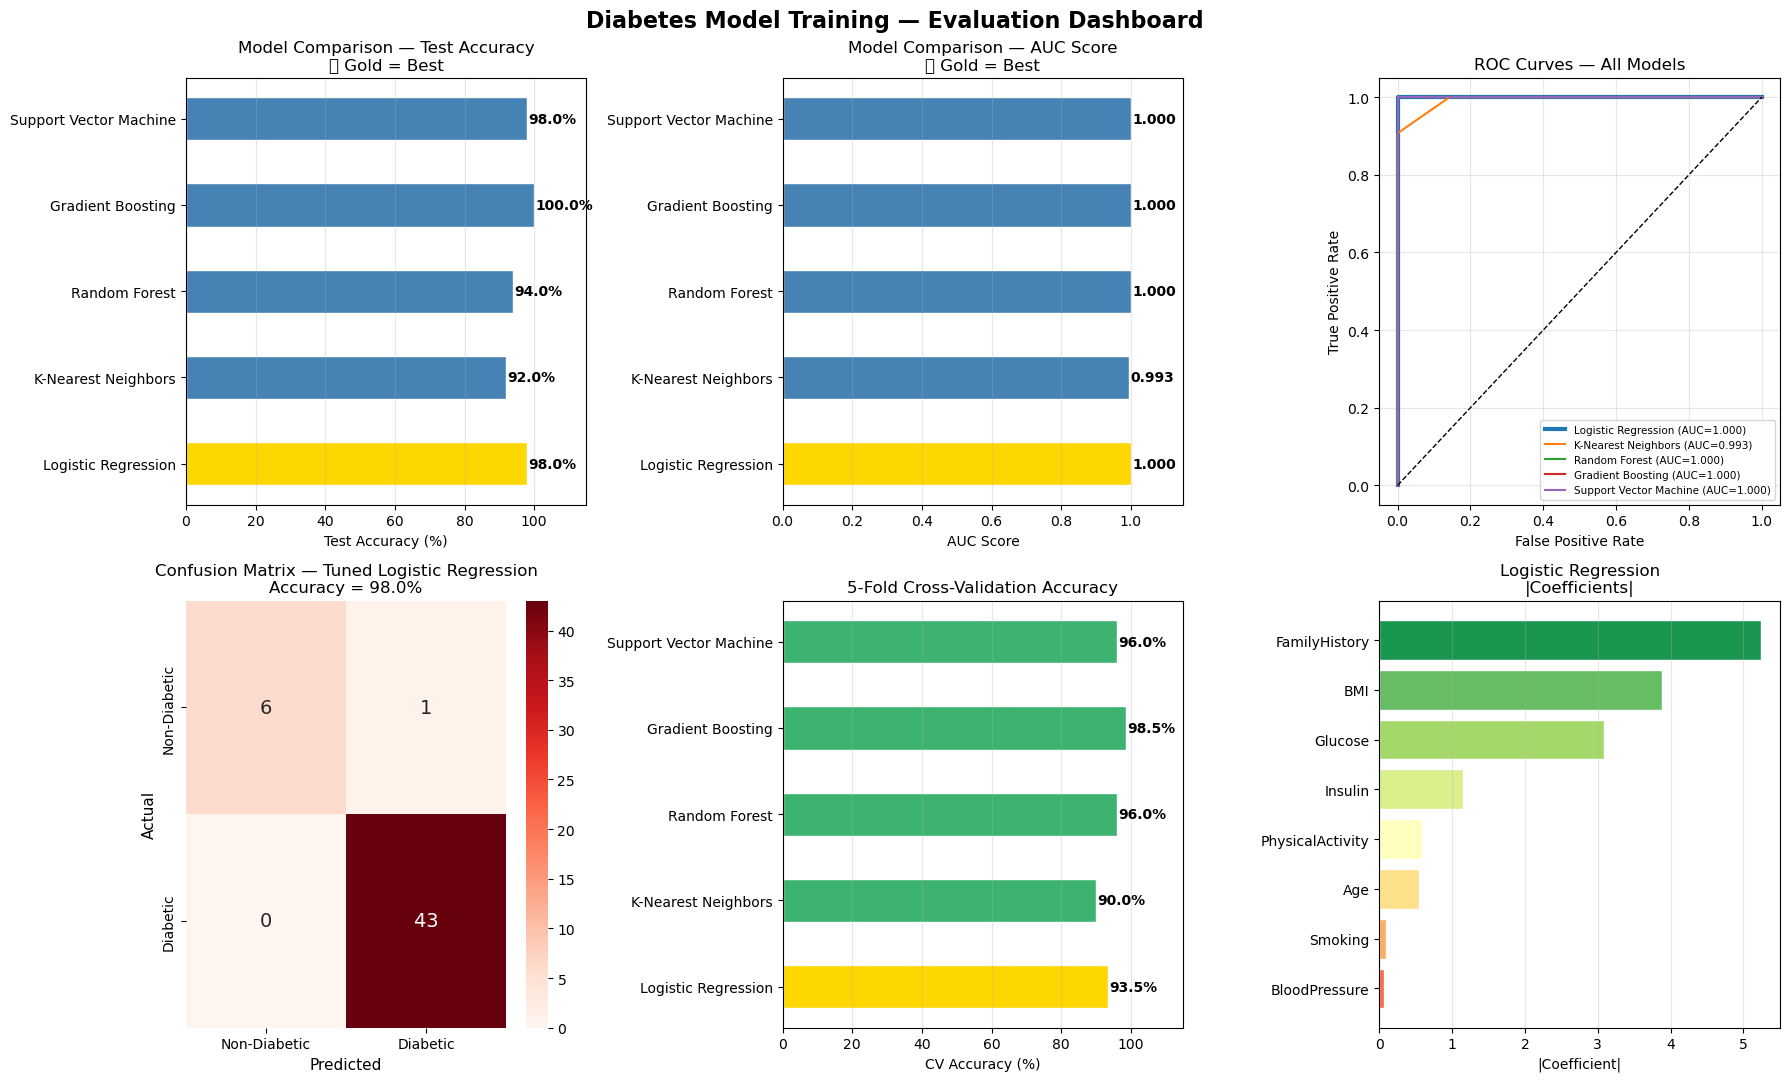


✅ Dashboard saved  →  diabetes_training_results.png

  🚀 HOW TO LOAD & PREDICT WITH THE SAVED MODEL

import joblib, numpy as np

scaler      = joblib.load('saved_models/scaler.pkl')
model       = joblib.load('saved_models/tuned_best_model.pkl')

# Feature order: Age, BMI, Glucose, BloodPressure,
#                Insulin, PhysicalActivity(0/1/2), FamilyHistory, Smoking
new_patient = np.array([[45, 28.5, 148, 85, 130, 1, 1, 0]])
new_scaled  = scaler.transform(new_patient)

prediction  = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)[:, 1]

print("Outcome    :", "Diabetic" if prediction[0] == 1 else "Non-Diabetic")
print("Probability:", f"{probability[0]*100:.1f}%")



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")

os.makedirs("saved_models", exist_ok=True)

# ═══════════════════════════════════════════════════════
# 1. LOAD & PREPROCESS
# ═══════════════════════════════════════════════════════
print("=" * 60)
print("         DIABETES MODEL TRAINING PIPELINE")
print("=" * 60)

df = pd.read_csv("diabetes_dataset_250.csv")
print(f"\n✅ Dataset loaded  →  {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nOutcome Distribution:\n{df['Outcome'].value_counts().to_string()}")

# Encode PhysicalActivity
df["PhysicalActivity"] = df["PhysicalActivity"].map({"Low": 0, "Medium": 1, "High": 2})

feature_cols = ["Age", "BMI", "Glucose", "BloodPressure",
                "Insulin", "PhysicalActivity", "FamilyHistory", "Smoking"]

X = df[feature_cols]
y = df["Outcome"]

# ═══════════════════════════════════════════════════════
# 2. TRAIN / TEST SPLIT
# ═══════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Train size : {X_train.shape[0]} samples")
print(f"📊 Test  size : {X_test.shape[0]} samples")

# ═══════════════════════════════════════════════════════
# 3. FEATURE SCALING
# ═══════════════════════════════════════════════════════
scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler for deployment
joblib.dump(scaler, "saved_models/scaler.pkl")
print("\n💾 Scaler saved  →  saved_models/scaler.pkl")

# ═══════════════════════════════════════════════════════
# 4. DEFINE & TRAIN MULTIPLE MODELS
# ═══════════════════════════════════════════════════════
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=7),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
}

print("\n" + "=" * 60)
print("           TRAINING & EVALUATING ALL MODELS")
print("=" * 60)

results = {}

for name, model in models.items():
    print(f"\n🔄 Training  →  {name} ...")
    model.fit(X_train_sc, y_train)

    y_pred      = model.predict(X_test_sc)
    y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc_ = roc_auc_score(y_test, y_pred_prob)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring="accuracy").mean()

    results[name] = {
        "model"      : model,
        "accuracy"   : acc,
        "auc"        : auc_,
        "cv_accuracy": cv,
        "y_pred"     : y_pred,
        "y_pred_prob": y_pred_prob,
    }

    print(f"   ✔ Test Accuracy : {acc*100:.2f}%")
    print(f"   ✔ AUC Score     : {auc_:.4f}")
    print(f"   ✔ CV Accuracy   : {cv*100:.2f}%  (5-fold)")

    # Save each model
    fname = f"saved_models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, fname)
    print(f"   💾 Saved  →  {fname}")

# ═══════════════════════════════════════════════════════
# 5. SELECT BEST MODEL
# ═══════════════════════════════════════════════════════
best_name  = max(results, key=lambda k: results[k]["auc"])
best       = results[best_name]
best_model = best["model"]

print("\n" + "=" * 60)
print(f"  🏆 BEST MODEL  :  {best_name}")
print(f"     Accuracy    :  {best['accuracy']*100:.2f}%")
print(f"     AUC Score   :  {best['auc']:.4f}")
print(f"     CV Accuracy :  {best['cv_accuracy']*100:.2f}%")
print("=" * 60)

joblib.dump(best_model, "saved_models/best_model.pkl")
print(f"\n💾 Best model saved  →  saved_models/best_model.pkl")

# ═══════════════════════════════════════════════════════
# 6. HYPERPARAMETER TUNING  (best model only)
# ═══════════════════════════════════════════════════════
print(f"\n🔧 Hyperparameter Tuning  →  {best_name} ...")

param_grids = {
    "Logistic Regression"   : {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]},
    "K-Nearest Neighbors"   : {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]},
    "Random Forest"         : {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10]},
    "Gradient Boosting"     : {"n_estimators": [50, 100, 200], "learning_rate": [0.05, 0.1, 0.2]},
    "Support Vector Machine": {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
}

grid = GridSearchCV(
    models[best_name],
    param_grids[best_name],
    cv=5, scoring="roc_auc", n_jobs=-1, verbose=0
)
grid.fit(X_train_sc, y_train)

tuned_model    = grid.best_estimator_
tuned_pred     = tuned_model.predict(X_test_sc)
tuned_prob     = tuned_model.predict_proba(X_test_sc)[:, 1]
tuned_acc      = accuracy_score(y_test, tuned_pred)
tuned_auc      = roc_auc_score(y_test, tuned_prob)

print(f"   Best Params  :  {grid.best_params_}")
print(f"   Tuned Acc    :  {tuned_acc*100:.2f}%")
print(f"   Tuned AUC    :  {tuned_auc:.4f}")

joblib.dump(tuned_model, "saved_models/tuned_best_model.pkl")
print("   💾 Tuned model saved  →  saved_models/tuned_best_model.pkl")

# ═══════════════════════════════════════════════════════
# 7. FULL CLASSIFICATION REPORT
# ═══════════════════════════════════════════════════════
print(f"\n📋 Classification Report — Tuned {best_name}:\n")
print(classification_report(y_test, tuned_pred,
                             target_names=["Non-Diabetic", "Diabetic"]))

# ═══════════════════════════════════════════════════════
# 8. VISUALISATIONS
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Diabetes Model Training — Evaluation Dashboard",
             fontsize=16, fontweight="bold")

# ── Plot 1: Model Comparison — Accuracy ──
ax = axes[0, 0]
names = list(results.keys())
accs  = [results[n]["accuracy"]*100 for n in names]
colors = ["gold" if n == best_name else "steelblue" for n in names]
bars = ax.barh(names, accs, color=colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 115)
ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Model Comparison — Test Accuracy\n⭐ Gold = Best")
ax.grid(axis="x", alpha=0.3)

# ── Plot 2: Model Comparison — AUC ──
ax = axes[0, 1]
aucs = [results[n]["auc"] for n in names]
bars = ax.barh(names, aucs, color=colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1.15)
ax.set_xlabel("AUC Score")
ax.set_title("Model Comparison — AUC Score\n⭐ Gold = Best")
ax.grid(axis="x", alpha=0.3)

# ── Plot 3: ROC Curves — All Models ──
ax = axes[0, 2]
cmap = plt.cm.get_cmap("tab10")
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_pred_prob"])
    lw = 3 if name == best_name else 1.5
    ax.plot(fpr, tpr, lw=lw, color=cmap(i),
            label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=7.5, loc="lower right")
ax.grid(alpha=0.3)

# ── Plot 4: Confusion Matrix — Tuned Best Model ──
ax = axes[1, 0]
cm = confusion_matrix(y_test, tuned_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax,
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"],
            annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"Confusion Matrix — Tuned {best_name}\nAccuracy = {tuned_acc*100:.1f}%")

# ── Plot 5: CV Scores Comparison ──
ax = axes[1, 1]
cv_scores = [results[n]["cv_accuracy"]*100 for n in names]
bar_colors = ["gold" if n == best_name else "mediumseagreen" for n in names]
bars = ax.barh(names, cv_scores, color=bar_colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 115)
ax.set_xlabel("CV Accuracy (%)")
ax.set_title("5-Fold Cross-Validation Accuracy")
ax.grid(axis="x", alpha=0.3)

# ── Plot 6: Feature Importance / Coefficients ──
ax = axes[1, 2]
if hasattr(tuned_model, "feature_importances_"):
    importances = tuned_model.feature_importances_
    title_suffix = "Feature Importances"
    xlabel = "Importance"
elif hasattr(tuned_model, "coef_"):
    importances = np.abs(tuned_model.coef_[0])
    title_suffix = "|Coefficients|"
    xlabel = "|Coefficient|"
else:
    importances = np.ones(len(feature_cols))
    title_suffix = "Feature Weights"
    xlabel = "Weight"

feat_imp = pd.DataFrame({"Feature": feature_cols, "Score": importances})
feat_imp = feat_imp.sort_values("Score", ascending=True)
bar_c = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
ax.barh(feat_imp["Feature"], feat_imp["Score"], color=bar_c, edgecolor="white")
ax.set_title(f"{best_name}\n{title_suffix}")
ax.set_xlabel(xlabel)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("diabetes_training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Dashboard saved  →  diabetes_training_results.png")

# ═══════════════════════════════════════════════════════
# 9. HOW TO LOAD & USE SAVED MODEL
# ═══════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  🚀 HOW TO LOAD & PREDICT WITH THE SAVED MODEL")
print("=" * 60)
print("""
import joblib, numpy as np

scaler      = joblib.load('saved_models/scaler.pkl')
model       = joblib.load('saved_models/tuned_best_model.pkl')

# Feature order: Age, BMI, Glucose, BloodPressure,
#                Insulin, PhysicalActivity(0/1/2), FamilyHistory, Smoking
new_patient = np.array([[45, 28.5, 148, 85, 130, 1, 1, 0]])
new_scaled  = scaler.transform(new_patient)

prediction  = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)[:, 1]

print("Outcome    :", "Diabetic" if prediction[0] == 1 else "Non-Diabetic")
print("Probability:", f"{probability[0]*100:.1f}%")
""")